In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df_a = pd.read_csv('Datasets/BostonHousing.csv')
print("Initial shape:", df_a.shape)
df_a.head()

Initial shape: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
n_duplicates = df_a.duplicated().sum()
print(f"Found {n_duplicates} duplicate rows.")

Found 0 duplicate rows.


In [4]:
print("\nMissing values per column:")
print(df_a.isnull().sum())


Missing values per column:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


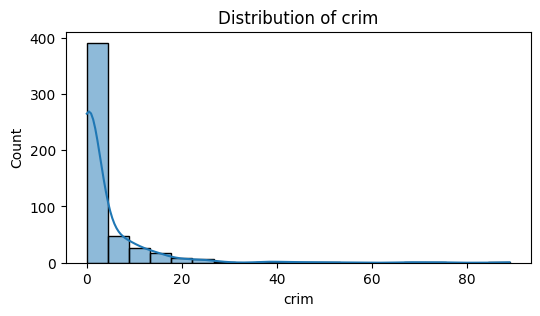

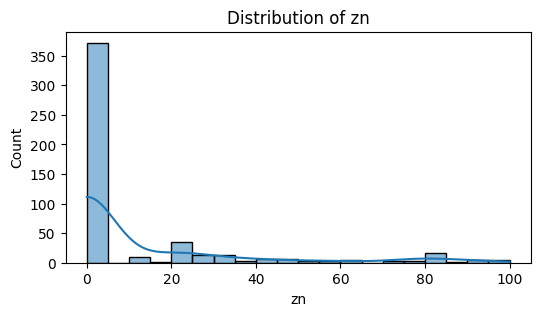

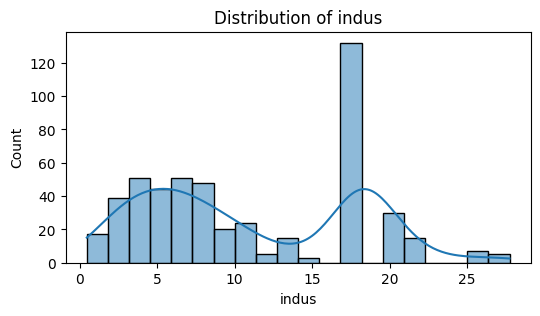

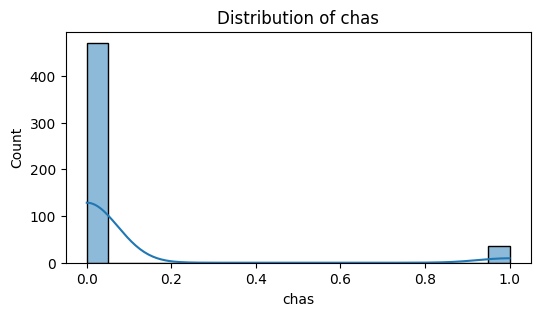

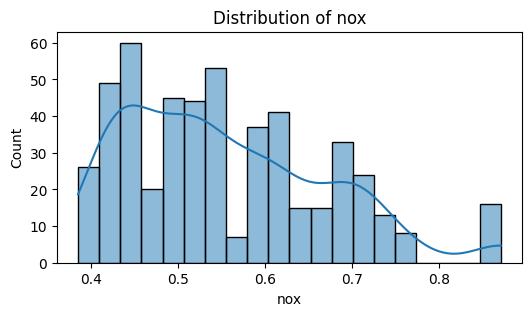

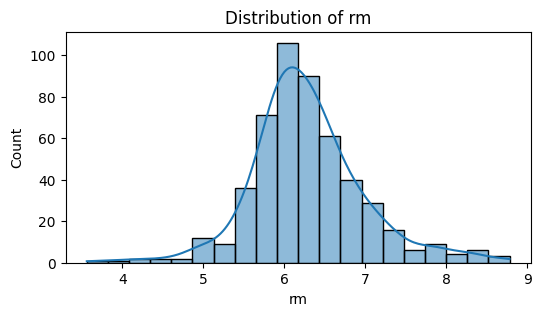

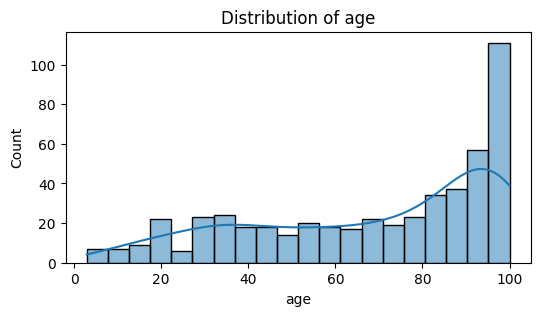

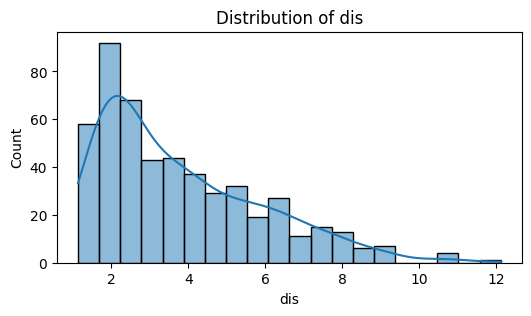

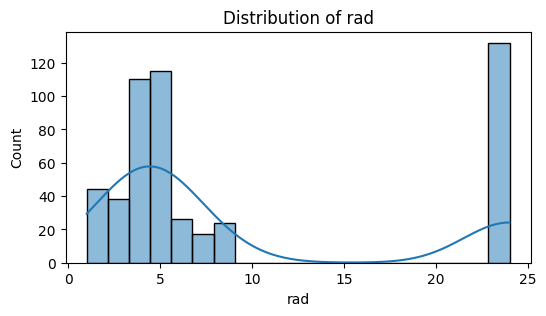

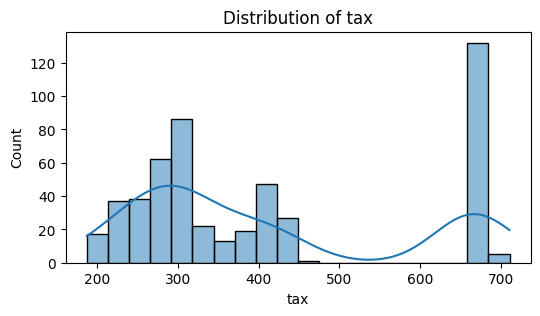

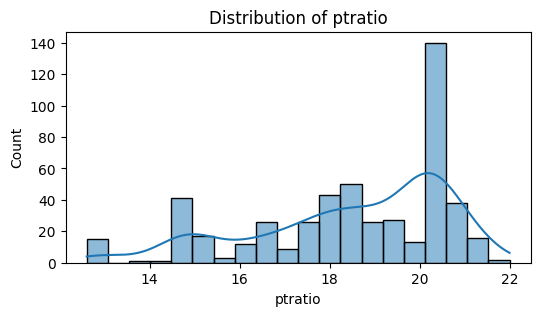

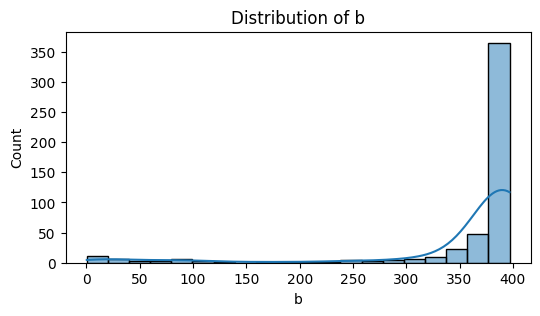

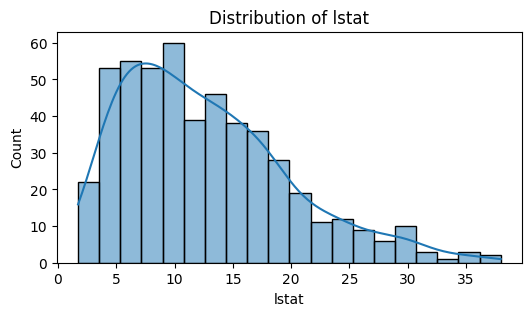

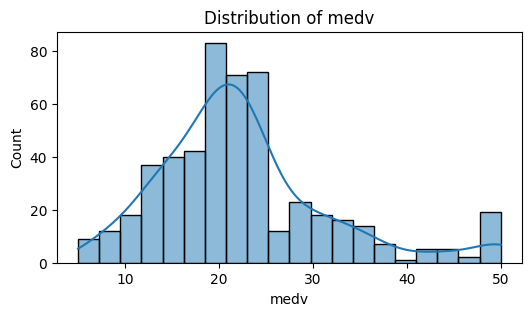

In [5]:
Columns = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']
for col in Columns:
    plt.figure(figsize=(6,3))
    sns.histplot(df_a[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()

In [6]:
outlier_indices = dict()
from scipy import stats
for col in Columns:
    skewness = df_a[col].skew()
    print(f"\nColumn: {col:<15} skewness = {skewness:.2f}")
    
    if abs(skewness) < 0.5:
        # approximately normal → Z-score method
        zscores = np.abs(stats.zscore(df_a[col]))
        mask = zscores > 3
        method = '|Z-score| > 3'
    else:
        # skewed → IQR method
        Q1 = df_a[col].quantile(0.25)
        Q3 = df_a[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        mask = (df_a[col] < lower) | (df_a[col] > upper)
        method = 'IQR 1.5× range'
    
    idx = df_a[mask].index
    outlier_indices[col] = idx
    print(f"  Detected {len(idx)} outliers by {method}.")



Column: crim            skewness = 5.22
  Detected 66 outliers by IQR 1.5× range.

Column: zn              skewness = 2.23
  Detected 68 outliers by IQR 1.5× range.

Column: indus           skewness = 0.30
  Detected 0 outliers by |Z-score| > 3.

Column: chas            skewness = 3.41
  Detected 35 outliers by IQR 1.5× range.

Column: nox             skewness = 0.73
  Detected 0 outliers by IQR 1.5× range.

Column: rm              skewness = 0.40
  Detected 8 outliers by |Z-score| > 3.

Column: age             skewness = -0.60
  Detected 0 outliers by IQR 1.5× range.

Column: dis             skewness = 1.01
  Detected 5 outliers by IQR 1.5× range.

Column: rad             skewness = 1.00
  Detected 0 outliers by IQR 1.5× range.

Column: tax             skewness = 0.67
  Detected 0 outliers by IQR 1.5× range.

Column: ptratio         skewness = -0.80
  Detected 15 outliers by IQR 1.5× range.

Column: b               skewness = -2.89
  Detected 77 outliers by IQR 1.5× range.

Column: l

In [7]:
normal_cols = [
    col for col in Columns
    if abs(df_a[col].skew()) < 0.5
]
df_b = df_a.drop(index=np.concatenate([outlier_indices[c] 
                                           for c in normal_cols])).reset_index(drop=True)
print("\nShape after trimming normal-dist outliers:", df_b.shape)
df_b.head()


Shape after trimming normal-dist outliers: (498, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [8]:
df_c = df_b
skewed_cols = [
    col for col in Columns
    if abs(df_b[col].skew()) >= 0.5
]
for col in skewed_cols:
    df_c[f'Log_{col}'] = np.log1p(df_c[col])
print("\nShape after log-transforming skewed columns:", df_c.shape)
df_c.head()


Shape after log-transforming skewed columns: (498, 27)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,...,Log_nox,Log_rm,Log_age,Log_dis,Log_rad,Log_tax,Log_ptratio,Log_b,Log_lstat,Log_medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,...,0.430483,2.024853,4.192680,1.627278,0.693147,5.693732,2.791165,5.986201,1.788421,3.218876
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,...,0.384582,2.004314,4.380776,1.786261,1.098612,5.493061,2.933857,5.986201,2.316488,3.117950
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,...,0.384582,2.102303,4.128746,1.786261,1.098612,5.493061,2.933857,5.975919,1.615420,3.575151
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,...,0.377066,2.079192,3.845883,1.954757,1.386294,5.407172,2.980619,5.980479,1.371181,3.538057
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,...,0.377066,2.097650,4.010963,1.954757,1.386294,5.407172,2.980619,5.986201,1.845300,3.616309


In [9]:
df_d = df_c
df_d.drop(columns=skewed_cols, inplace=True)
print("\nShape after deleting original skewed columns:", df_d.shape)
df_d.head()


Shape after deleting original skewed columns: (498, 14)


,indus,Log_crim,Log_zn,Log_chas,Log_nox,Log_rm,Log_age,Log_dis,Log_rad,Log_tax,Log_ptratio,Log_b,Log_lstat,Log_medv
0,2.31,0.006300,2.944439,0.0,0.430483,2.024853,4.192680,1.627278,0.693147,5.693732,2.791165,5.986201,1.788421,3.218876
1,7.07,0.026944,0.000000,0.0,0.384582,2.004314,4.380776,1.786261,1.098612,5.493061,2.933857,5.986201,2.316488,3.117950
2,7.07,0.026924,0.000000,0.0,0.384582,2.102303,4.128746,1.786261,1.098612,5.493061,2.933857,5.975919,1.615420,3.575151
3,2.18,0.031857,0.000000,0.0,0.377066,2.079192,3.845883,1.954757,1.386294,5.407172,2.980619,5.980479,1.371181,3.538057
4,2.18,0.066770,0.000000,0.0,0.377066,2.097650,4.010963,1.954757,1.386294,5.407172,2.980619,5.986201,1.845300,3.616309


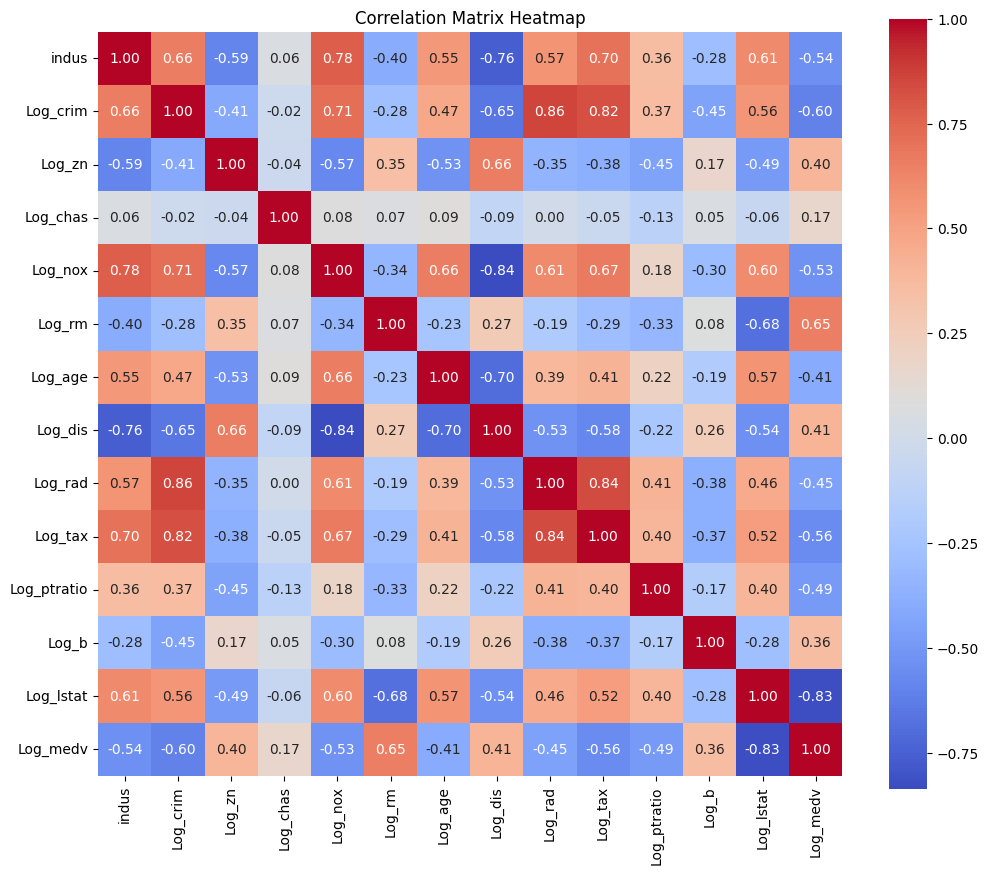

In [10]:
# 3.	Apply correlation analysis for the entire dataset. Visualize that by an appropriate tool such as heatmap.

corr_matrix = df_d.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [11]:

df = df_d
target_col = 'Log_medv'
predictor_cols = [col for col in df.columns if col != target_col]
correlations = df[predictor_cols].corrwith(df[target_col])
independent_cols = correlations[correlations.abs() < 0.3].index.tolist()
df_final = df.drop(columns=independent_cols)
print("\nShape after removing low-correlation predictors:", df_final.shape)
df_final.head()


Shape after removing low-correlation predictors: (498, 13)


,indus,Log_crim,Log_zn,Log_nox,Log_rm,Log_age,Log_dis,Log_rad,Log_tax,Log_ptratio,Log_b,Log_lstat,Log_medv
0,2.31,0.006300,2.944439,0.430483,2.024853,4.192680,1.627278,0.693147,5.693732,2.791165,5.986201,1.788421,3.218876
1,7.07,0.026944,0.000000,0.384582,2.004314,4.380776,1.786261,1.098612,5.493061,2.933857,5.986201,2.316488,3.117950
2,7.07,0.026924,0.000000,0.384582,2.102303,4.128746,1.786261,1.098612,5.493061,2.933857,5.975919,1.615420,3.575151
3,2.18,0.031857,0.000000,0.377066,2.079192,3.845883,1.954757,1.386294,5.407172,2.980619,5.980479,1.371181,3.538057
4,2.18,0.066770,0.000000,0.377066,2.097650,4.010963,1.954757,1.386294,5.407172,2.980619,5.986201,1.845300,3.616309


In [12]:

all_corr_matrix = df_final.corr().abs()
upper_tri = all_corr_matrix.where(np.triu(np.ones(all_corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.7)]
df_final_ = df_final.drop(columns=to_drop)
print("\nShape after removing collinear predictors:", df_final.shape)
df_final_.head()


Shape after removing collinear predictors: (498, 13)


,indus,Log_crim,Log_zn,Log_rm,Log_age,Log_ptratio,Log_b,Log_lstat
0,2.31,0.006300,2.944439,2.024853,4.192680,2.791165,5.986201,1.788421
1,7.07,0.026944,0.000000,2.004314,4.380776,2.933857,5.986201,2.316488
2,7.07,0.026924,0.000000,2.102303,4.128746,2.933857,5.975919,1.615420
3,2.18,0.031857,0.000000,2.079192,3.845883,2.980619,5.980479,1.371181
4,2.18,0.066770,0.000000,2.097650,4.010963,2.980619,5.986201,1.845300


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [14]:
df_final_.head()

,indus,Log_crim,Log_zn,Log_rm,Log_age,Log_ptratio,Log_b,Log_lstat
0,2.31,0.006300,2.944439,2.024853,4.192680,2.791165,5.986201,1.788421
1,7.07,0.026944,0.000000,2.004314,4.380776,2.933857,5.986201,2.316488
2,7.07,0.026924,0.000000,2.102303,4.128746,2.933857,5.975919,1.615420
3,2.18,0.031857,0.000000,2.079192,3.845883,2.980619,5.980479,1.371181
4,2.18,0.066770,0.000000,2.097650,4.010963,2.980619,5.986201,1.845300


In [15]:
X = df_final
y = df_final[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [16]:
df_predictions = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
df_predictions.head()

,Actual,Predicted
487,3.182212,3.182212
73,3.194583,3.194583
231,3.754199,3.754199
175,3.414443,3.414443
237,3.206803,3.206803


In [17]:
def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

print("Model Performance:")
print(f"RMSE: {compute_metrics(y_test, y_pred)[0]:.4f}")
print(f"R2: {compute_metrics(y_test, y_pred)[1]:.44f}")

Model Performance:
RMSE: 0.0000
R2: 1.00000000000000000000000000000000000000000000


In [18]:
# 7.	Apply ANOVA test to check for significance of the predictors.
anova_results = dict()
from scipy.stats import f_oneway
for col in X_train.columns:
    groups = []
    for level in np.unique(X_train[col]):
        group = y_train[X_train[col] == level]
        groups.append(group)
    f_stat, p_value = f_oneway(*groups)
    anova_results[col] = (f_stat, p_value)
    
print("\nANOVA Test Results:")
for col, (f_stat, p_value) in anova_results.items():
    print(f"Predictor: {col:<15} F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")


ANOVA Test Results:
Predictor: indus           F-statistic = 4.4909, p-value = 0.0000
Predictor: Log_crim        F-statistic = 0.6303, p-value = 0.7940
Predictor: Log_zn          F-statistic = 3.6204, p-value = 0.0000
Predictor: Log_nox         F-statistic = 14.2532, p-value = 0.0000
Predictor: Log_rm          F-statistic = 1.8005, p-value = 0.0156
Predictor: Log_age         F-statistic = 0.6720, p-value = 0.9946
Predictor: Log_dis         F-statistic = 6.2482, p-value = 0.0000
Predictor: Log_rad         F-statistic = 20.7390, p-value = 0.0000
Predictor: Log_tax         F-statistic = 3.9698, p-value = 0.0000
Predictor: Log_ptratio     F-statistic = 5.7203, p-value = 0.0000
Predictor: Log_b           F-statistic = 1.0064, p-value = 0.4924
Predictor: Log_lstat       F-statistic = 3.1408, p-value = 0.0001
Predictor: Log_medv        F-statistic = inf, p-value = 0.0000


/Users/manuel/Documents/UNF/Predictive Analytics/.venv/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


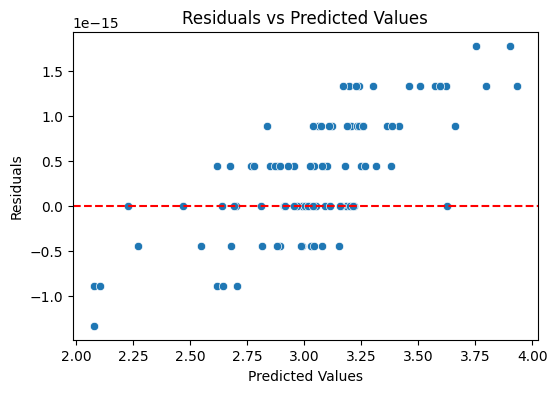

In [19]:
# 8.	Visualize residuals for the overall model and also for every single predictor. It is important to check for any non-linearity, auto-regression (although it is not applicable here) and heteroscedasticity. 
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

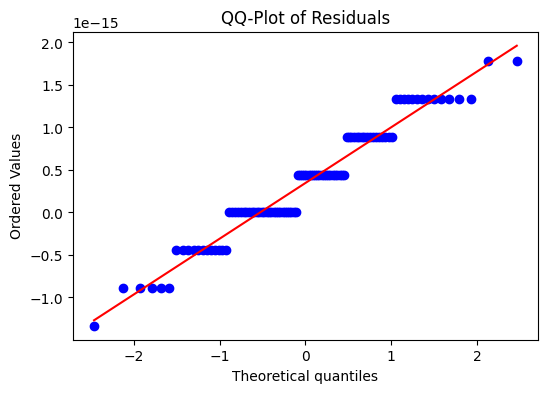

In [20]:
# 9.	Visualize normality check by an appropriate tool such as QQ-Plot and/or histogram for the overall model and also for every single predictor. It is required to implement normality check.
import scipy.stats as stats
plt.figure(figsize=(6,4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-Plot of Residuals")
plt.show()

In [21]:
# 10.	Predict one sample case based on the model provided.
sample_case = X_test.iloc[0].values.reshape(1, -1)
predicted_value = model.predict(sample_case)
print("\nSample Case Prediction:")
print(f"Predicted Log_medv: {predicted_value[0]:.4f}")


Sample Case Prediction:
Predicted Log_medv: 3.1822


/Users/manuel/Documents/UNF/Predictive Analytics/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
